In [ ]:
#pip install kagglehub

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

import datetime as dt


# Load data

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "2019-Oct.csv"

# Loading dataset with pandas kwargs
df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"mkechinov/ecommerce-behavior-data-from-multi-category-store",
"2019-Oct.csv",
pandas_kwargs={
"nrows": 500_000,
"dtype": {
'event_type': 'category',
'product_id': 'int32',
'category_code': 'category',
'brand': 'category',
'price': 'float32',
'user_id': 'int32',
}
}
)


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_3304/1897145881.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [67]:
df = df.drop_duplicates()

In [68]:
df.shape

(499712, 9)

In [69]:
df['event_type'].value_counts(normalize=True)

event_type
view        0.964135
purchase    0.019525
cart        0.016339
Name: proportion, dtype: float64

In [3]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [4]:
cut_time = df['event_time'].max()

In [5]:
cut_time

'2019-10-01 16:56:07 UTC'

In [6]:
past   = df[df['event_time'] <= cut_time]
future = df[df['event_time'] >  cut_time]

In [4]:
list_category_code = ['electronics.smartphone',
'electronics.audio.headphone',
'electronics.clocks',
'computers.notebook',
'electronics.video.tv'
]


In [5]:
df_elec=df[df['category_code'].isin(list_category_code)]

In [ ]:
df_elec['date'] = df_elec['event_time'].apply(lambda s : str(s)[0:10])

In [ ]:
df_elec['hour'] = df_elec['event_time'].apply(lambda s : str(s)[10:19])

In [ ]:

df_elec['date'] = pd.to_datetime(df_elec['date'])

In [ ]:
df_elec['week_of_day'] = df_elec['date'].dt.day_name()

In [5]:
df_elec['event_type_str'] = df_elec['event_type'].astype(str)
df_elec.sort_values(by=['user_id', 'user_session', 'product_id', 'event_time'])
df_elec['event_time']=pd.to_datetime(df_elec['event_time'])


/tmp/ipykernel_3048/1888376266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_type_str'] = df_elec['event_type'].astype(str)
/tmp/ipykernel_3048/1888376266.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_time']=pd.to_datetime(df_elec['event_time'])


In [ ]:

df_events_v2 = df_elec.groupby(['user_id', 'user_session'])['event_type_str'].apply(lambda x: pd.Series([x.iloc[i] if i < len(x) else ' ' for i in range(8)
              ], index=['event1', 'event2', 'event3','event4', 'event5', 'event6','event7', 'event8' ])).reset_index()
df_events_v2.pivot(index=['user_id', 'user_session'], columns='level_2', values='event_type_str')
df_events_v2.head(10)

In [11]:
df_elec['event_time'] = df_elec['event_time'].astype(str)

/tmp/ipykernel_6220/1570059409.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_time'] = df_elec['event_time'].astype(str)


In [ ]:
df_events_v2_pivot = df_events_v2.pivot(index=['user_id', 'user_session'], columns='level_2', values='event_type_str').reset_index()

In [ ]:
df_events_v2_pivot.head(10)

#Buliding sequence of events

In [ ]:
#time sequence per user id, user session
df_events_time = df_elec.groupby(['user_id', 'user_session'])['event_time'].apply(lambda x: pd.Series([x.iloc[i] if i < len(x) else ' ' for i in range(8)
              ], index=['time1', 'time2', 'time3','time4', 'time5', 'time6','time7', 'time8' ])).reset_index()
df_events_time_pivot = df_events_time.pivot(index=['user_id', 'user_session'], columns='level_2', values='event_time').reset_index()
df_events_time_pivot.head(10)

In [7]:
#event sequence and duration mean per user id, user session
import numpy as np
df_events = df_elec.groupby(['user_id', 'user_session', 'category_id']).agg({
    'event_type_str' : " ".join,
    'event_time' : (lambda x : max(x) - min(x)),
    'product_id' : (lambda x : np.size(x))
}).reset_index()

In [8]:
df_events['seq_list'] = df_events['event_type_str'].apply(str.split)
df_events['seq_list_1'] = df_events['seq_list'].apply(lambda x : x[:-1])
df_events['target'] = df_events['seq_list'].apply(lambda x : x[-1])
df_events['seq_one'] = df_events['seq_list_1'].apply(lambda x : ['one_view'] if x==[] else x)
df_events['seq'] = df_events.agg({'seq_one' : " ".join })




#df_events['seq_1'] = df_events.groupby(['user_id', 'user_session'])['seq_list'].apply(lambda x: x[:-1])

#df_events_time['target'] = df_events.groupby(['user_id', 'user_session'])['event_type_str'].apply(lambda x: x[-1])

/tmp/ipykernel_3048/204725043.py:5: FutureWarning: using <built-in method join of str object at 0x7b47c9fb3f70> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df_events['seq'] = df_events.agg({'seq_one' : " ".join })


In [9]:
df_events = df_events.rename(columns={'event_time':'duration', 'product_id' : 'nb_product'})

In [10]:
df_events['sequence_len'] = df_events['seq'].apply(lambda x : len(x.split()))
df_events['duration_mean']=df_events['duration']/df_events['sequence_len']
df_events['duration_mean_sec'] = df_events['duration_mean'].dt.total_seconds()

In [11]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55094 entries, 0 to 55093
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype          
---  ------             --------------  -----          
 0   user_id            55094 non-null  int32          
 1   user_session       55094 non-null  object         
 2   category_id        55094 non-null  int64          
 3   event_type_str     55094 non-null  object         
 4   duration           55094 non-null  timedelta64[ns]
 5   nb_product         55094 non-null  int64          
 6   seq_list           55094 non-null  object         
 7   seq_list_1         55094 non-null  object         
 8   target             55094 non-null  object         
 9   seq_one            55094 non-null  object         
 10  seq                55094 non-null  object         
 11  sequence_len       55094 non-null  int64          
 12  duration_mean      55094 non-null  timedelta64[ns]
 13  duration_mean_sec  55094 non-null  float64    

In [12]:
df_price = df_elec.groupby(['user_id', 'user_session', 'category_id']).agg(
    price_median=('price', 'median'),
    price_iqr=('price', lambda x: x.quantile(0.75) - x.quantile(0.25))
)

In [13]:
df_price['price_dispersion'] = df_price['price_iqr'] / df_price['price_median']


In [14]:
df_price.shape

(55094, 3)

In [15]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 55094 entries, (np.int32(244951053), '91769fdf-461b-4e43-9c73-88a07481b75c', np.int64(2053013555631882655)) to (np.int32(555584028), '9947dc97-9691-4bf4-abf7-a37c8a411e0d', np.int64(2053013555631882655))
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price_median      55094 non-null  float32
 1   price_iqr         55094 non-null  float64
 2   price_dispersion  55070 non-null  float64
dtypes: float32(1), float64(2)
memory usage: 2.1+ MB


In [16]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55094 entries, 0 to 55093
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype          
---  ------             --------------  -----          
 0   user_id            55094 non-null  int32          
 1   user_session       55094 non-null  object         
 2   category_id        55094 non-null  int64          
 3   event_type_str     55094 non-null  object         
 4   duration           55094 non-null  timedelta64[ns]
 5   nb_product         55094 non-null  int64          
 6   seq_list           55094 non-null  object         
 7   seq_list_1         55094 non-null  object         
 8   target             55094 non-null  object         
 9   seq_one            55094 non-null  object         
 10  seq                55094 non-null  object         
 11  sequence_len       55094 non-null  int64          
 12  duration_mean      55094 non-null  timedelta64[ns]
 13  duration_mean_sec  55094 non-null  float64    

In [ ]:
#df_events['event_time_list'] = df_events['event_time'].apply(str.split)
#df_events['event_time_1'] = df_events['event_time_list'].apply(lambda x : x[:-1])
#df_events['time_to target'] = df_events['event_time_list'].apply(lambda x : x[-1])
#df_events['seq'] = df_events.agg({'seq_list_1' : " ".join })

In [17]:
df_events.shape

(55094, 14)

In [17]:
df_events_price = pd.merge(df_events, df_price, on = ['user_id', 'user_session', 'category_id'])

In [21]:
df_events_price.shape

(107991, 17)

In [ ]:
#df_events_2 = pd.merge(df_events, df_elec.loc[:,['user_id', 'user_session', 'product_id', 'event_time']], on=['user_id', 'user_session', 'product_id'], how='left')

In [22]:
df_events_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107991 entries, 0 to 107990
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype          
---  ------             --------------   -----          
 0   user_id            107991 non-null  int32          
 1   user_session       107991 non-null  object         
 2   category_id        107991 non-null  int64          
 3   event_type_str     107991 non-null  object         
 4   duration           107991 non-null  timedelta64[ns]
 5   nb_product         107991 non-null  int64          
 6   seq_list           107991 non-null  object         
 7   seq_list_1         107991 non-null  object         
 8   target             107991 non-null  object         
 9   seq_one            107991 non-null  object         
 10  seq                107991 non-null  object         
 11  sequence_len       107991 non-null  int64          
 12  duration_mean      107991 non-null  timedelta64[ns]
 13  duration_mean_sec  107991 non

In [18]:
df_events_price['target'].value_counts()

target
view        52301
purchase     2005
cart          788
Name: count, dtype: int64

In [19]:
df_events_price['target_0_1'] = df_events_price['target'].apply(lambda x : 1 if x=='purchase' else 0)

In [20]:
df_events_price['target_0_1'].value_counts(normalize=True)

target_0_1
0    0.963608
1    0.036392
Name: proportion, dtype: float64

In [21]:
df_events_price.describe()

,user_id,category_id,duration,nb_product,sequence_len,duration_mean,duration_mean_sec,price_median,price_iqr,price_dispersion,target_0_1
count,5.509400e+04,5.509400e+04,55094,55094.000000,55094.000000,55094,55094.000000,55094.000000,55094.000000,55070.000000,55094.000000
mean,5.335460e+08,2.053047e+18,0 days 00:03:56.660525647,3.490416,2.884779,0 days 00:01:16.684691540,76.684692,485.894775,58.506501,0.151864,0.036392
std,1.710318e+07,1.372117e+15,0 days 00:15:40.172830893,4.560387,4.367115,0 days 00:09:25.736898558,565.736899,436.076508,147.991642,1.026344,0.187266
min,2.449511e+08,2.053014e+18,0 days 00:00:00,1.000000,1.000000,0 days 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.164016e+08,2.053014e+18,0 days 00:00:00,1.000000,1.000000,0 days 00:00:00,0.000000,171.559998,0.000000,0.000000,0.000000
50%,5.326711e+08,2.053014e+18,0 days 00:00:40,2.000000,1.000000,0 days 00:00:22.555555555,22.555556,301.079987,0.000000,0.000000,0.000000
75%,5.516653e+08,2.053014e+18,0 days 00:02:55,4.000000,3.000000,0 days 00:00:55.768571428,55.768571,736.179993,38.610001,0.141011,0.000000
max,5.555840e+08,2.109094e+18,0 days 08:59:23,139.000000,138.000000,0 days 08:59:23,32363.000000,2574.070068,2379.230095,183.011356,1.000000


In [22]:
#building of y dataframe
y = df_events_price['target_0_1']
#y_small = pd.DataFrame(df_event_feature_small['target_0_1'])

In [28]:
y.shape

(107991,)

In [23]:
X = df_events_price.loc[:,['category_id', 'seq','duration_mean_sec', 'sequence_len', 'nb_product', 'price_dispersion', 'price_median' ]]

In [30]:
X.isnull().sum()

category_id           0
seq                   0
duration_mean_sec     0
sequence_len          0
nb_product            0
price_dispersion     76
price_median          0
dtype: int64

In [29]:
X.head(5)

,category_id,seq,duration_mean_sec,sequence_len,nb_product,price_dispersion,price_median
0,2053013555631882655,view,53.00,1,2,0.000000,460.500000
1,2053013555631882655,view view,123.50,2,3,0.462062,241.179993
2,2053013554658804075,view view,112.00,2,3,0.086118,161.929993
3,2053013555631882655,view view view cart,38.25,4,5,0.062981,197.520004
4,2053013554658804075,one_view,0.00,1,1,0.000000,188.729996


In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify=y)

In [25]:
# Vérifier les infinis et NaN dans X_train brut
print("Infinis:", np.isinf(X_train.select_dtypes(include='number')).sum().sum())
print("NaN:", X_train.isna().sum().sum())
print("Valeurs max:", X_train.select_dtypes(include='number').max())

Infinis: 0
NaN: 18
Valeurs max: category_id          2.109094e+18
duration_mean_sec    3.223300e+04
sequence_len         1.380000e+02
nb_product           1.390000e+02
price_dispersion     1.830114e+02
price_median         2.574070e+03
dtype: float64


In [26]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

In [27]:
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector

from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
pipe_cat = Pipeline([('ohe',OneHotEncoder(sparse_output=False,

                        handle_unknown="ignore").set_output(transform="pandas"))])


In [28]:
pipe_num = Pipeline([('simple_impute', SimpleImputer(missing_values=np.nan, strategy='median')),
                     ('rb_scale', RobustScaler().set_output(transform="pandas"))])

In [29]:
col_transf = ColumnTransformer([
    ('cat_transform',pipe_cat, ["category_id", "seq"]),
    ('num_transform', pipe_num, ['sequence_len', 'duration_mean_sec', 'nb_product', 'price_dispersion', 'price_median'])
])

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, cross_val_predict, cross_val_score
pipe = Pipeline([
    ("preprocessing", col_transf),
    ("classifier", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [43]:
cv_result = cross_validate(pipe, X_train, y_train, cv = 5, scoring = ['precision', 'recall', 'f1'])

In [45]:
cv_result.keys()

dict_keys(['fit_time', 'score_time', 'test_precision', 'test_recall', 'test_f1'])

In [44]:
cv_result['test_f1'].mean()

np.float64(0.20294986088413416)

In [45]:
cv_result['test_recall'].mean()

np.float64(0.7983007598736671)

In [46]:
cv_result['test_precision'].mean()

np.float64(0.11625793741363628)

# Baseline model Regression Logistique

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, cross_val_predict, cross_val_score
from sklearn.metrics import classification_report


In [ ]:

model = pipe.fit(X_train, y_train)

In [ ]:

print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.80      0.89     20892
           1       0.12      0.82      0.21       707

    accuracy                           0.80     21599
   macro avg       0.56      0.81      0.55     21599
weighted avg       0.96      0.80      0.86     21599



### PR-AUC

In [143]:
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve, roc_auc_score, average_precision_score

cv = StratifiedKFold(n_splits=5)
cross_v_result = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision").mean()


KeyboardInterrupt: 

In [47]:
cross_v_result

np.float64(0.3681618455269874)

In [48]:
y_pred_prob = pipe.predict_proba(X_test)


In [49]:
y_pred_prob= y_pred_prob[:,1]

In [52]:
precision, recall, threshold = precision_recall_curve(y_test, y_pred_prob)

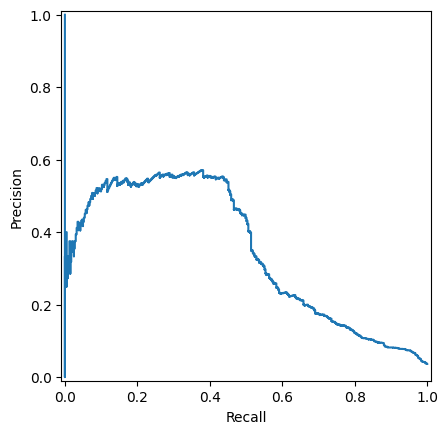

In [51]:

disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot();

In [ ]:
cross_v_result

np.float64(0.3634476473578629)

### threshold for a fixed recall

In [61]:
target_recall = 0.5

In [63]:
idx = np.argmin(target_recall - recall)
target_threshold = threshold[idx]

In [64]:
target_threshold

np.float64(4.073975812490632e-35)

### Calibration

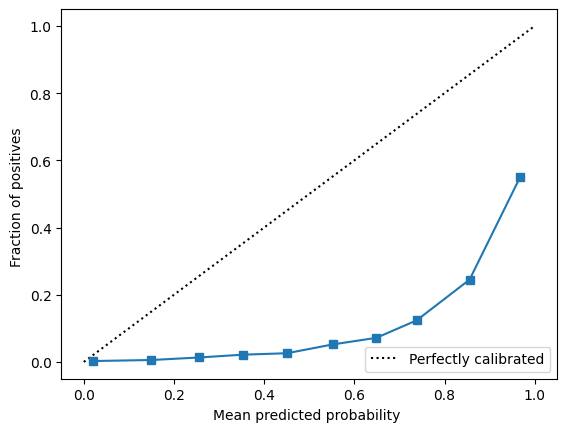

In [67]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob)
disp.plot();

In [68]:
calibrated_clf = CalibratedClassifierCV(pipe, cv=cv)
calibrated_clf.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=1000))])
,method,'sigmoid'
,cv,StratifiedKFo...shuffle=False)
,n_jobs,None
,ensemble,'auto'
,transformers,"[('cat_transform', ...), ('num_transform', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [ ]:
y_pred_prob = calibrated_clf.predict_proba(X_test)


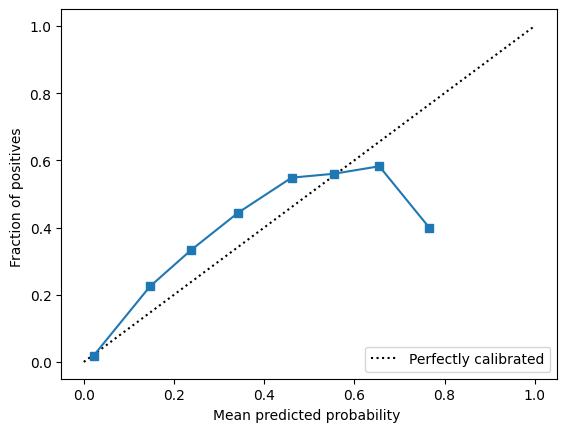

In [58]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob[:,1], n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob[:,1])
disp.plot();

### Under Sampling

In [98]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [99]:

from imblearn.under_sampling import TomekLinks

In [100]:


tl = TomekLinks()
X_train_res, y_train_res = tl.fit_resample(X_train_transformed, y_train)

print(X_train_res.shape)
print(y_train_res.shape)


(43524, 896)
(43524,)


In [63]:
y_train_res.value_counts(normalize=True)

target_0_1
0    0.962537
1    0.037463
Name: proportion, dtype: float64

### Feature importance

In [ ]:
feature_names = list(X_train.columns)

In [ ]:
from sklearn.inspection import permutation_importance
r = permutation_importance(log_reg, X_train, y_train,
                           n_repeats=5,
                           random_state=0)
for i in r.importances_mean.argsort()[::-1]:
    #if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
    print(f"{feature_names[i]:<8}"
            f"{r.importances_mean[i]:.3f}"
            f" +/- {r.importances_std[i]:.3f}")

KeyboardInterrupt: 

In [ ]:
r.importances_mean

In [ ]:
ft_importance = pd.DataFrame(r.importances_mean, feature_names).reset_index()

In [ ]:
ft_importance.head(10)

In [ ]:
X_train_preprocessed.shape

(44075, 920)

In [50]:
import numpy as np
from sklearn.model_selection import learning_curve

train_sizes = [25000, 30000, 50000, 65000]

# Get train scores (R2), train sizes, and validation scores using `learning_curve`
train_sizes, train_scores, test_scores = learning_curve(
    estimator=pipe, X=X_train, y=y_train, train_sizes=train_sizes, cv=5, scoring="recall")

# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)


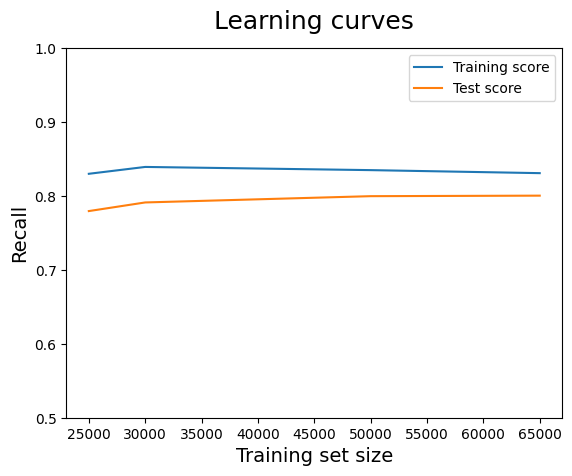

In [52]:
plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylim(0.5, 1)
plt.ylabel('Recall', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

In [90]:
pip install shap

  Using cached shap-0.49.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (25 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.64.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.9 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached llvmlite-0.46.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.0 kB)
Using cached shap-0.49.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.0 MB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numba-0.64.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.7 MB)
Using cached llvmlite-0.46.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (56.3 MB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]
Note: you may need to restart the kernel to use updated packages.


In [53]:
import shap
shap.initjs();

In [42]:
X_train_transformed = pipe.named_steps['preprocessing'].transform(X_train)
X_test_transformed = pipe.named_steps['preprocessing'].transform(X_test)

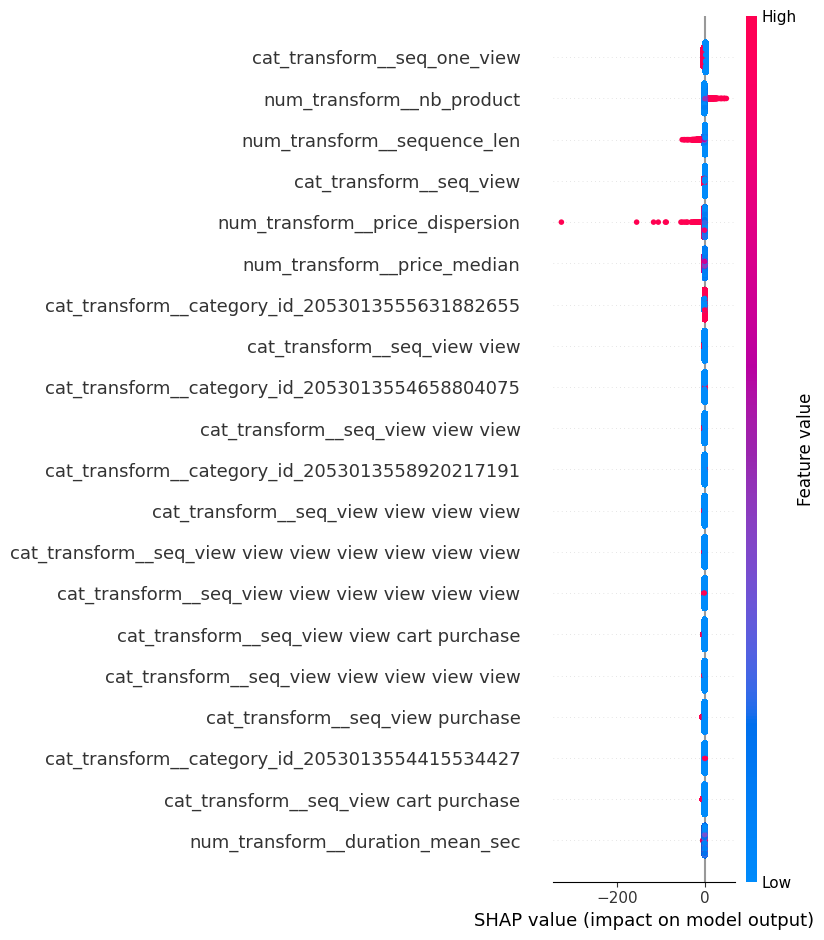

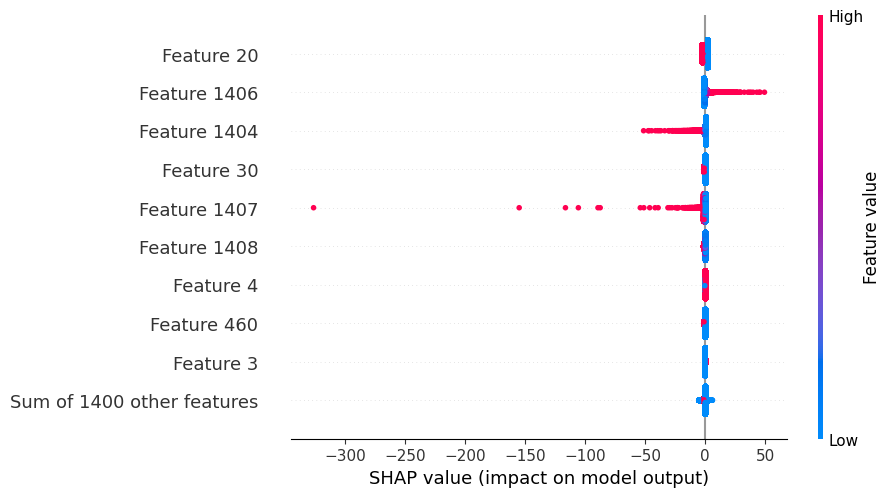

In [ ]:
# Extraire les données transformées et les noms de features

feature_names = pipe.named_steps['preprocessing'].get_feature_names_out()

# Passer predict_proba au lieu du pipeline entier
explainer = shap.LinearExplainer(
    pipe.named_steps['classifier'],
    X_train_transformed
)

shap_values = explainer(X_train_transformed)

shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)

shap.plots.beeswarm(shap_values)

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


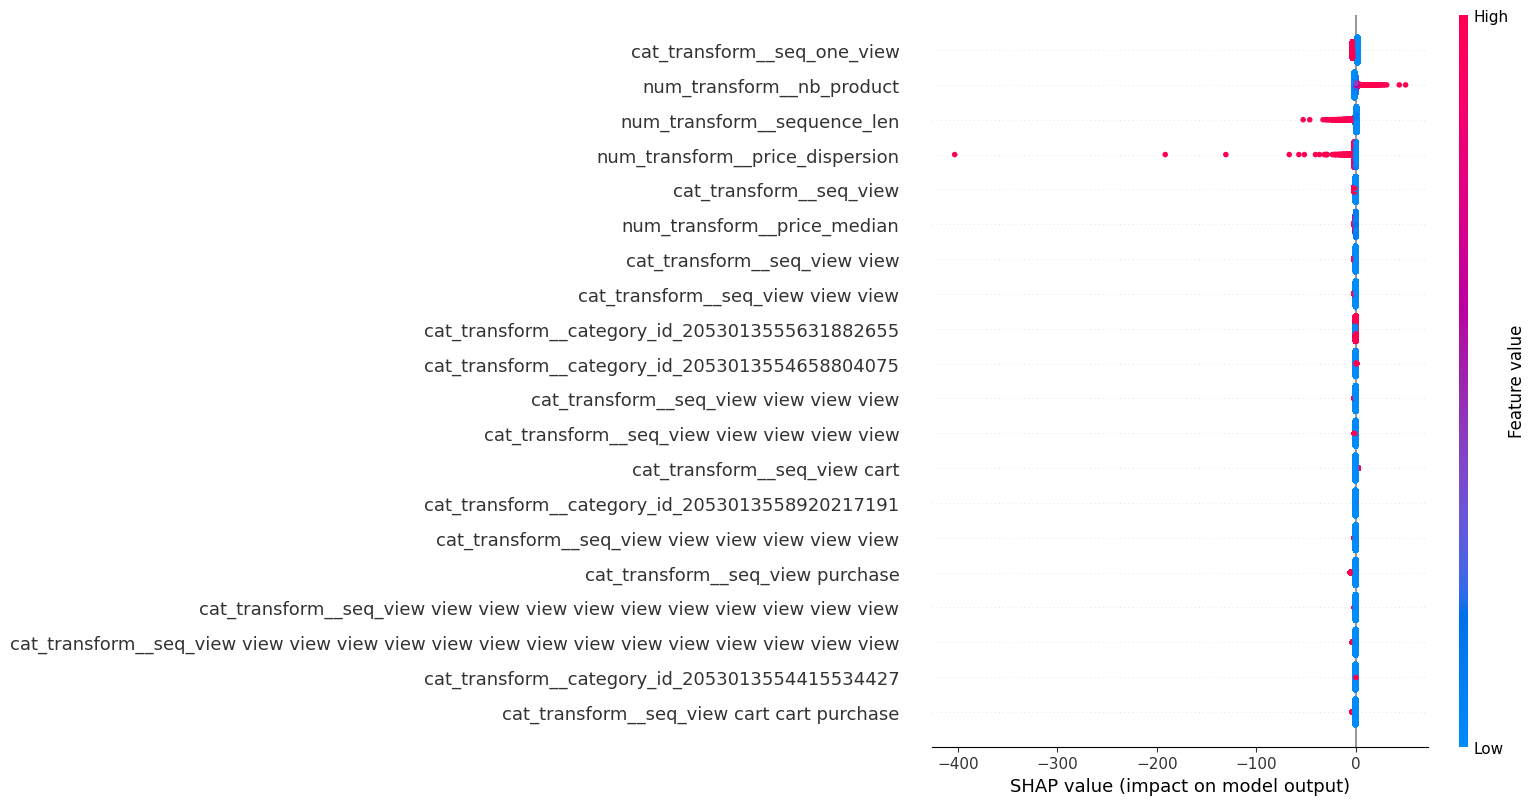

In [68]:
shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)


In [108]:
shap_values.values

array([[-0.00000000e+00, -9.32643352e-04, -2.99004723e-02, ...,
         6.73657813e-01, -1.78237898e-04, -7.95719961e-01],
       [-0.00000000e+00, -9.32643352e-04,  4.68440733e-01, ...,
        -3.11093664e+00,  9.14063657e-05,  2.97709020e+00],
       [-0.00000000e+00, -9.32643352e-04, -2.99004723e-02, ...,
         6.73657813e-01,  6.38132351e-05, -4.52737219e-01],
       ...,
       [-0.00000000e+00, -9.32643352e-04, -2.99004723e-02, ...,
        -1.59709886e+00,  3.83803735e-04,  1.60515923e+00],
       [-0.00000000e+00, -9.32643352e-04, -2.99004723e-02, ...,
         6.73657813e-01, -1.20606676e-04, -4.52737219e-01],
       [-0.00000000e+00, -9.32643352e-04, -2.99004723e-02, ...,
         6.73657813e-01, -1.78237898e-04, -7.95719961e-01]],
      shape=(44075, 912))

In [110]:
shap_df = pd.DataFrame(shap_values.values, columns = feature_names)

# XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:


# XGBoost — meilleur choix pour données tabulaires déséquilibrées
xgb = XGBClassifier(
    scale_pos_weight=97/3,  # gère le déséquilibre 3/97
    eval_metric='aucpr',    # optimise sur PR AUC
    random_state=42
)


In [ ]:




X_train_transformed = pipe.named_steps['preprocessing'].transform(X_train)
cv_result_xgb = cross_validate(xgb, X_train_transformed, y_train, cv = 5, scoring = ['precision', 'recall', 'f1'])

In [72]:
cv_result_xgb['test_f1'].mean()

np.float64(0.28401015656570755)

In [74]:
cv_result_xgb['test_precision'].mean()

np.float64(0.17193840515395006)

In [75]:
cv_result_xgb['test_recall'].mean()

np.float64(0.8167153426791277)

In [126]:
model_xgb = xgb.fit(X_train_transformed, y_train)

In [59]:
X_test_transformed = pipe.named_steps['preprocessing'].transform(X_test)

In [75]:
print(classification_report(y_test, xgb.predict(X_test_transformed)))

              precision    recall  f1-score   support

           0       0.99      0.84      0.91     10618
           1       0.16      0.83      0.27       401

    accuracy                           0.84     11019
   macro avg       0.58      0.83      0.59     11019
weighted avg       0.96      0.84      0.89     11019



In [89]:
cv = StratifiedKFold(n_splits=5)
cross_v_result = cross_val_score(model_xgb, X_train_transformed, y_train, cv=cv, scoring="average_precision").mean()

### PR AUC

In [90]:
cross_v_result

np.float64(0.40875549978151166)

In [91]:
y_pred_prob = model_xgb.predict_proba(X_test_transformed)

In [92]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob[:,1])

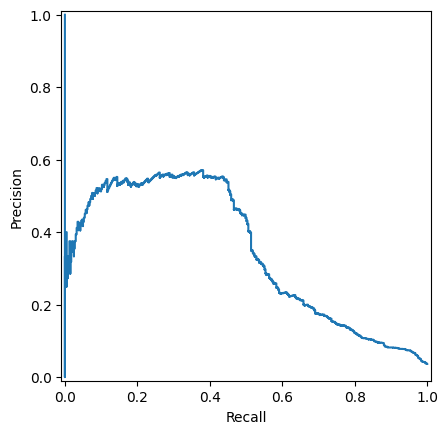

In [93]:
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot();

In [94]:
# Trouver le seuil pour recall cible
recall_cible = 0.5
idx = np.argmin(np.abs(recalls - recall_cible))
print(f"Seuil : {thresholds[idx]:.3f}")
print(f"Precision : {precisions[idx]:.3f}")
print(f"Recall : {recalls[idx]:.3f}")

Seuil : 0.867
Precision : 0.405
Recall : 0.501


### Learning curves XGBOOST

In [95]:
import numpy as np
from sklearn.model_selection import learning_curve

train_sizes = [7500, 10000,15000, 20000, 25000, 30000]

# Get train scores (R2), train sizes, and validation scores using `learning_curve`
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model_xgb, X=X_train_transformed, y=y_train, train_sizes=train_sizes, cv=5, scoring="recall")

# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)


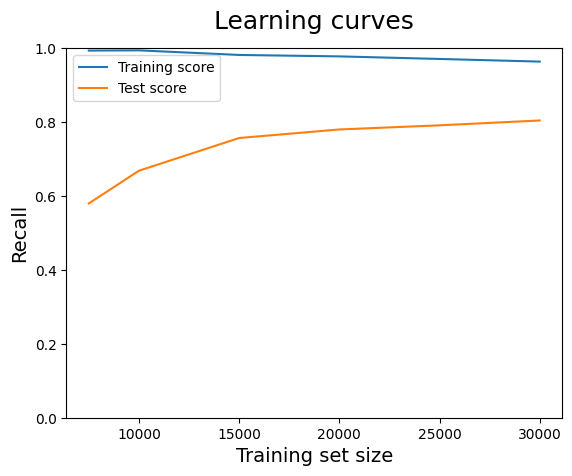

In [96]:
plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylim(0, 1)
plt.ylabel('Recall', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

### XGBOOST Calibration

In [98]:
y_pred_prob = y_pred_prob[:,1]

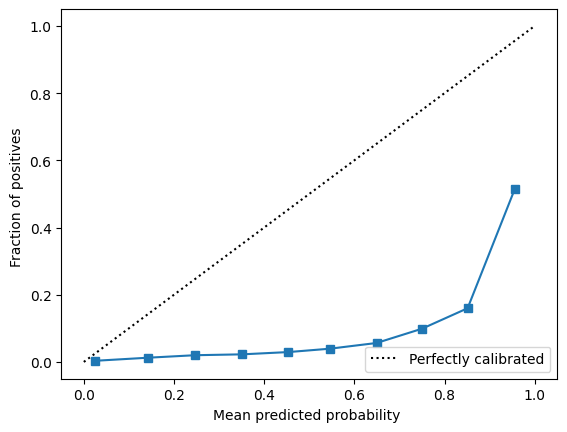

In [99]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob)
disp.plot();

In [100]:
calibrated_clf = CalibratedClassifierCV(xgb, cv=cv)
calibrated_clf.fit(X_train_transformed, y_train)
y_pred_prob = calibrated_clf.predict_proba(X_test_transformed)

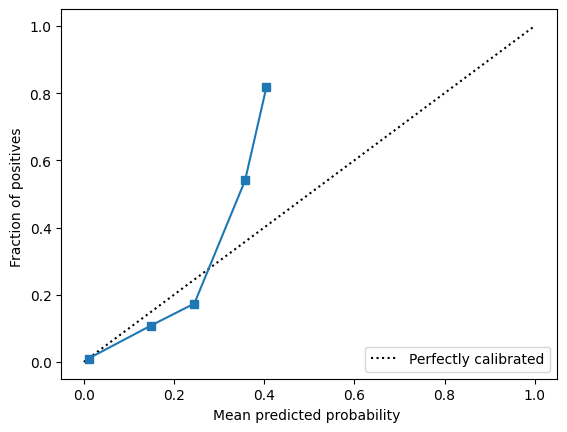

In [101]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob[:,1], n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob[:,1])
disp.plot();

### SHAP XGBOOST

In [40]:
feature_names = pipe.named_steps['preprocessing'].get_feature_names_out()

In [41]:
X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
).astype(float)

NameError: name 'X_test_transformed' is not defined

In [122]:
X_train_transformed.dtype

dtype('float64')

In [109]:
X_test_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11019 entries, 0 to 11018
Columns: 896 entries, cat_transform__category_id_2053013552603594983 to num_transform__price_median
dtypes: float64(896)
memory usage: 75.3 MB


In [130]:
# Step 1: Create a SHAP Explainer
explainer = shap.TreeExplainer(model_xgb)


ValueError: could not convert string to float: '[5.4961514E-1]'

In [ ]:
#explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer(X_test_transformed)


In [ ]:
# Step 2: Calculate the SHAP values
# Using the explainer we just created
# and giving as input the feature values for our instance
shap_values_one = explainer(feature_values)

## LightGBM

In [31]:

import lightgbm as lgb
from lightgbm import LGBMClassifier
print(lgb.__version__)

4.6.0


In [32]:
nb_0 = y_train[y_train ==0].size
nb_1 = y_train[y_train ==1].size
ratio = nb_0 / nb_1

In [33]:
ratio

26.478179551122196

In [37]:
X_train_transformed = pipe.named_steps['preprocessing'].transform(X_train)

In [45]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.04,
    max_depth=5,
    num_leaves=40,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=ratio,
    objective="binary",
    n_jobs=-1,
    metric=["AUC", 'precision','recall','f1']
)






model.fit(
    X_train_transformed, y_train,
    eval_set=[(X_test_transformed, y_test)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)
print(classification_report(y_test, model.predict(X_test_transformed)))
preds = model.predict(X_test_transformed)
proba = model.predict_proba(X_test_transformed)


[LightGBM] [Info] Number of positive: 1604, number of negative: 42471
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1000
[LightGBM] [Info] Number of data points in the train set: 44075, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.036393 -> initscore=-3.276321
[LightGBM] [Info] Start training from score -3.276321
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [61]:

train_sizes = [25000, 30000, 50000, 65000]

# Get train scores (R2), train sizes, and validation scores using `learning_curve`
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model, X=X_train_transformed, y=y_train, train_sizes=train_sizes, cv=5, scoring="recall")

# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

[LightGBM] [Info] Number of positive: 840, number of negative: 24160
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005739 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 966
[LightGBM] [Info] Number of data points in the train set: 25000, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033600 -> initscore=-3.359052
[LightGBM] [Info] Start training from score -3.359052
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1013, number of negative: 28987
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003008 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 976
[LightGBM] [Info] Number of data points in the train set: 30000, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033767 -> initscore=-3.353931
[LightGBM] [Info] Start training from score -3.353931
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1689, number of negative: 48311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002717 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1018
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033780 -> initscore=-3.353523
[LightGBM] [Info] Start training from score -3.353523
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2139, number of negative: 62861
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1030
[LightGBM] [Info] Number of data points in the train set: 65000, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032908 -> initscore=-3.380588
[LightGBM] [Info] Start training from score -3.380588
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 839, number of negative: 24161
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006434 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 958
[LightGBM] [Info] Number of data points in the train set: 25000, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033560 -> initscore=-3.360284
[LightGBM] [Info] Start training from score -3.360284
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1012, number of negative: 28988
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 974
[LightGBM] [Info] Number of data points in the train set: 30000, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033733 -> initscore=-3.354953
[LightGBM] [Info] Start training from score -3.354953
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1688, number of negative: 48312
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004004 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1016
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033760 -> initscore=-3.354136
[LightGBM] [Info] Start training from score -3.354136
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2138, number of negative: 62862
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003170 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1030
[LightGBM] [Info] Number of data points in the train set: 65000, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032892 -> initscore=-3.381071
[LightGBM] [Info] Start training from score -3.381071
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 876, number of negative: 24124
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 960
[LightGBM] [Info] Number of data points in the train set: 25000, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035040 -> initscore=-3.315596
[LightGBM] [Info] Start training from score -3.315596
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1049, number of negative: 28951
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051766 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 968
[LightGBM] [Info] Number of data points in the train set: 30000, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034967 -> initscore=-3.317767
[LightGBM] [Info] Start training from score -3.317767
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1689, number of negative: 48311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1018
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033780 -> initscore=-3.353523
[LightGBM] [Info] Start training from score -3.353523
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2139, number of negative: 62861
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003634 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1038
[LightGBM] [Info] Number of data points in the train set: 65000, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032908 -> initscore=-3.380588
[LightGBM] [Info] Start training from score -3.380588
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 876, number of negative: 24124
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 960
[LightGBM] [Info] Number of data points in the train set: 25000, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035040 -> initscore=-3.315596
[LightGBM] [Info] Start training from score -3.315596
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1049, number of negative: 28951
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001598 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 968
[LightGBM] [Info] Number of data points in the train set: 30000, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034967 -> initscore=-3.317767
[LightGBM] [Info] Start training from score -3.317767
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1690, number of negative: 48310
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1014
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033800 -> initscore=-3.352910
[LightGBM] [Info] Start training from score -3.352910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2139, number of negative: 62861
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007670 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1032
[LightGBM] [Info] Number of data points in the train set: 65000, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032908 -> initscore=-3.380588
[LightGBM] [Info] Start training from score -3.380588
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 876, number of negative: 24124
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001292 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 960
[LightGBM] [Info] Number of data points in the train set: 25000, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035040 -> initscore=-3.315596
[LightGBM] [Info] Start training from score -3.315596
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1049, number of negative: 28951
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007591 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 968
[LightGBM] [Info] Number of data points in the train set: 30000, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034967 -> initscore=-3.317767
[LightGBM] [Info] Start training from score -3.317767
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1690, number of negative: 48310
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007508 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1014
[LightGBM] [Info] Number of data points in the train set: 50000, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033800 -> initscore=-3.352910
[LightGBM] [Info] Start training from score -3.352910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2190, number of negative: 62810
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.067659 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1030
[LightGBM] [Info] Number of data points in the train set: 65000, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033692 -> initscore=-3.356213
[LightGBM] [Info] Start training from score -3.356213
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


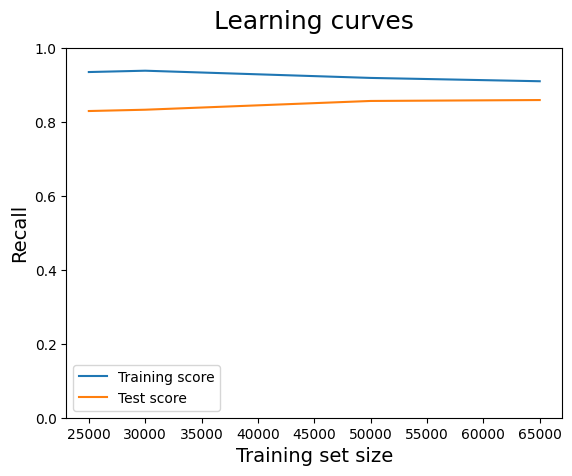

In [62]:
plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylim(0, 1)
plt.ylabel('Recall', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

In [ ]:
grid =

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy import stats

# Instantiate model
model = model

# Hyperparameter Grid
grid = {'n_estimators': [100, 200,300, 400 , 500, 700, 900],
        'learning_rate': [0.005, 0.01, 0.05, 0.1],
        'max_depth' : [2, 3, 4, 5, 6, 7, 8],
        'num_leaves' : [10, 20, 30, 40, 50, 60]}

# Instantiate Grid Search
search = RandomizedSearchCV(
    model,
    grid,
    scoring='average_precision',
    n_iter=100,  # number of draws
    cv=5, n_jobs=-1
)

# Fit data to Grid Search


In [ ]:
search.fit(X_train_transformed, y_train)
search.best_estimator_

In [ ]:

from itertools import combinations

events = df['event_type'].unique()

def compute_transition_features(session_events: list) -> dict:
    """
    Calcule toutes les features de transition pour une session.
    session_events : liste ordonnée des événements, ex: ['view','view','cart','purchase']
    """
    features = {}

    # --- 1. Matrice de transition brute (counts) ---
    for e1 in events:
        for e2 in events:
            features[f'trans_{e1}_to_{e2}'] = 0

    for i in range(len(session_events) - 1):
        e1, e2 = session_events[i], session_events[i+1]
        if e1 in events and e2 in events:
            features[f'trans_{e1}_to_{e2}'] += 1


    # --- 2. Matrice de transition normalisée (probabilités) ---
    for e1 in events:
        total_from_e1 = sum(
            features[f'trans_{e1}_to_{e2}'] for e2 in events
        )
        for e2 in events:
            features[f'prob_{e1}_to_{e2}'] = (
                features[f'trans_{e1}_to_{e2}'] / total_from_e1
                if total_from_e1 > 0 else 0.0
            )

    # --- 3. Features comportementales dérivées ---
    n = len(session_events)

    # Momentum : dernier événement
    features['last_event_is_cart']    = int(session_events[-1] == 'cart')
    features['last_event_is_view']    = int(session_events[-1] == 'view')
    features['last_event_is_remove']  = int(session_events[-1] == 'remove_from_cart')

    # Hésitation : ratio remove/cart
    n_cart   = session_events.count('cart')
    n_remove = session_events.count('remove_from_cart')
    features['hesitation_ratio'] = n_remove / n_cart if n_cart > 0 else 0.0
    features['cart_abandoned']   = int(n_cart > 0 and session_events[-1] != 'purchase')

    # Linéarité : séquence directe view→cart sans retour en arrière
    features['view_cart_direct'] = int(
        'view' in session_events
        and 'cart' in session_events
        and session_events.index('cart') > session_events.index('view')
        and n_remove == 0
    )

    # Profondeur : à quel % de la session le premier cart apparaît
    cart_indices = [i for i, e in enumerate(session_events) if e == 'cart']
    features['first_cart_depth']  = cart_indices[0] / n  if cart_indices else 1.0
    features['last_cart_depth']   = cart_indices[-1] / n if cart_indices else 1.0

    # Entropie de la séquence (séquence chaotique vs linéaire)
    counts = np.array([session_events.count(e) for e in events])
    probs  = counts / counts.sum()
    features['seq_entropy'] = -np.sum(
        p * np.log2(p) for p in probs if p > 0
    )

    # Patterns spécifiques (bigrams critiques)
    bigrams = [f"{session_events[i]}_{session_events[i+1]}"
               for i in range(n - 1)]
    features['has_view_cart_bigram']   = int('view_cart' in bigrams)
    features['has_cart_remove_bigram'] = int('cart_remove_from_cart' in bigrams)
    features['has_cart_view_bigram']   = int('cart_view' in bigrams)  # hésitation
    return features


# --- Exemple d'application sur ton dataframe ---
# En supposant que tu as déjà une colonne 'event_sequence' (liste d'events par session)

df_features = df.groupby(['user_id', 'user_session'])['event_type'].apply(list).reset_index()
df_features.columns = ['user_id', 'user_session', 'event_sequence']

transition_df = df_features['event_sequence'].apply(
    lambda seq: pd.Series(compute_transition_features(seq))
)

df_final = pd.concat([df_features, transition_df], axis=1)

In [46]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.metrics import average_precision_score, make_scorer
from sklearn.model_selection import cross_validate
import pandas as pd

In [ ]:


#métrique principale AVG PRECISION
ap_scorer = make_scorer(average_precision_score, needs_proba=True)

samplers = {
    # --- Undersampling ---

    #"under_random_20"  : RandomUnderSampler(sampling_strategy=0.2,  random_state=42),

    #"enn"              : EditedNearestNeighbours(),

    # --- Oversampling ---
    #""over_random"      : RandomOverSampler(sampling_strategy=0.1,   random_state=42),
    #"smote_10"         : SMOTE(sampling_strategy=0.1, random_state=42),
    #"smote_20"         : SMOTE(sampling_strategy=0.2, random_state=42),
    # --- Combiné ---

    "smote_enn"        : SMOTEENN(random_state=42),
}

results = []


In [52]:
for name, sampler in samplers.items():
    pipe_imb = ImbPipeline([
        ("preprocessing", col_transf),
        ("sampler",       sampler),
        ("classifier",    model)
    ])

    cv = cross_validate(
        pipe_imb, X_train, y_train, cv=5,
        scoring={
            'ap'      : ap_scorer,
            'roc_auc' : 'roc_auc',
            'f1'      : 'f1',
        },
        n_jobs=-1
    )

    results.append({
        'sampler'      : name,
        'AP_mean'      : cv['test_ap'].mean(),
        'AP_std'       : cv['test_ap'].std(),
        'ROC_AUC_mean' : cv['test_roc_auc'].mean(),
        'F1_mean'      : cv['test_f1'].mean(),
    })

[LightGBM] [Info] Number of positive: 30598, number of negative: 29064
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.410554 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10345
[LightGBM] [Info] Number of data points in the train set: 59662, number of used features: 236
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512856 -> initscore=0.051434
[LightGBM] [Info] Start training from score 0.051434
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/_param_valid

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/_param_valid

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/_param_valid

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/_param_valid

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
  File "/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/sklearn/

In [53]:
results

[{'sampler': 'smote_enn',
  'AP_mean': np.float64(nan),
  'AP_std': np.float64(nan),
  'ROC_AUC_mean': np.float64(0.9171246487732956),
  'F1_mean': np.float64(0.19675926423513324)}]

In [6]:
df_elec.head(100)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb
11,2019-10-01 00:00:11 UTC,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101
16,2019-10-01 00:00:18 UTC,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5
...,...,...,...,...,...,...,...,...,...
252,2019-10-01 00:03:35 UTC,view,1005115,2053013555631882655,electronics.smartphone,apple,975.570007,519829701,c3012f56-70f3-4198-960d-5f14467c0a53
256,2019-10-01 00:03:39 UTC,view,1004946,2053013555631882655,electronics.smartphone,oneplus,746.219971,533205672,698f6680-5fcf-4bf0-af14-cea6366052d5
258,2019-10-01 00:03:42 UTC,view,1005105,2053013555631882655,electronics.smartphone,apple,1415.479980,554190174,46279e69-5c2a-4c3c-945b-460268bc683c
263,2019-10-01 00:03:46 UTC,view,5100561,2053013553341792533,electronics.clocks,garmin,859.729980,522806189,9fc424df-a04f-4051-8f18-4c637491d007


In [ ]:
df_elec['event_type_str'] = df_elec['event_type'].astype(str)
df_elec.sort_values(by=['user_id', 'user_session', 'product_id', 'event_time'])


/tmp/ipykernel_3304/1888376266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_type_str'] = df_elec['event_type'].astype(str)
/tmp/ipykernel_3304/1888376266.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_time']=pd.to_datetime(df_elec['event_time'])


In [9]:
df_rnn = df_elec.groupby(['user_id', 'user_session', 'category_id']).agg(
    sequence =('event_type_str', lambda x : " ".join(x.iloc[:len(x)-1]) if len(x)>1 else 'one_view'),
    target =('event_type_str', lambda x : x.iloc[len(x)-1])
    ).reset_index()

In [10]:
df_rnn['target_0_1'] = df_rnn['target'].apply(
    lambda x : 1 if x == 'purchase' else 0
)

In [11]:
df_rnn['target'].value_counts()

target
view        52301
purchase     2005
cart          788
Name: count, dtype: int64

In [12]:
df_rnn['target_0_1'].value_counts(normalize=True)

target_0_1
0    0.963608
1    0.036392
Name: proportion, dtype: float64

In [13]:
df_rnn['len_seq'] = df_rnn['sequence'].apply(lambda x : len(x))

In [14]:
df_rnn['len_seq'].describe()

count    55094.000000
mean        15.273387
std         21.549778
min          4.000000
25%          8.000000
50%          8.000000
75%         14.000000
max        693.000000
Name: len_seq, dtype: float64

<Axes: >

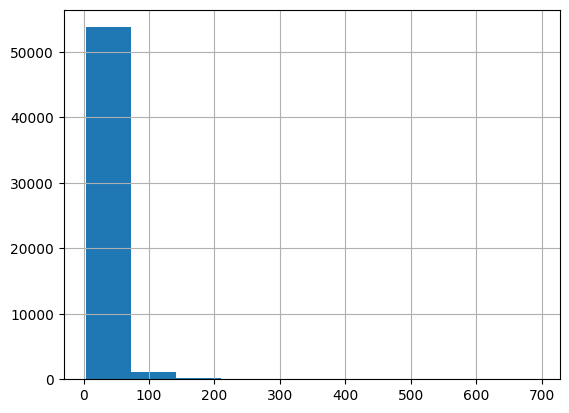

In [15]:
df_rnn['len_seq'].hist()

In [16]:
df_rnn = df_rnn[df_rnn['len_seq']<80]

In [17]:
df_rnn.shape

(54089, 7)

In [105]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [18]:
df_elec['event_time'] = pd.to_datetime(df_elec['event_time'])

df_elec['event_time_utc'] = df_elec['event_time'].dt.tz_localize(None)
df_elec['event_time_str'] = df_elec['event_time_utc'].astype(str)


/tmp/ipykernel_3304/3374089561.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_time'] = pd.to_datetime(df_elec['event_time'])
/tmp/ipykernel_3304/3374089561.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_time_utc'] = df_elec['event_time'].dt.tz_localize(None)
/tmp/ipykernel_3304/3374089561.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

In [250]:

df_time = df_elec.groupby(['user_id', 'user_session', 'category_id']).agg(
    time_sequence = ('event_time_str', lambda x : list(x.iloc[:(len(x)-1)])),
    time_sequence_target = ('event_time_str', lambda x : x.iloc[len(x)-1])
).reset_index()

In [251]:
df_time.head()

,user_id,user_session,category_id,time_sequence,time_sequence_target
0,244951053,91769fdf-461b-4e43-9c73-88a07481b75c,2053013555631882655,[2019-10-01 08:47:35],2019-10-01 08:48:28
1,362972137,a7d81604-ed16-4bf2-afc3-386d12f26547,2053013555631882655,"[2019-10-01 09:41:49, 2019-10-01 09:42:58]",2019-10-01 09:45:56
2,376375533,e0b2446d-e6fa-4993-a0f6-2efbde5f3d93,2053013554658804075,"[2019-10-01 09:21:42, 2019-10-01 09:22:00]",2019-10-01 09:25:26
3,386070015,49d03116-3c95-4e13-8b9c-e3be97551fe8,2053013555631882655,"[2019-10-01 05:01:02, 2019-10-01 05:01:53, 201...",2019-10-01 05:03:35
4,390315979,8efe5b01-a233-424e-b801-b34e50bc9478,2053013554658804075,[],2019-10-01 06:59:54


In [254]:
print(type(df_time['time_sequence'].iloc[0]))

<class 'list'>


In [255]:
df_rnn_evt_time = pd.merge(df_rnn, df_time, on = ['user_id', 'user_session','category_id'], how = 'inner')

In [256]:
df_rnn_evt_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54089 entries, 0 to 54088
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   user_id               54089 non-null  int32 
 1   user_session          54089 non-null  object
 2   category_id           54089 non-null  int64 
 3   sequence              54089 non-null  object
 4   target                54089 non-null  object
 5   target_0_1            54089 non-null  int64 
 6   len_seq               54089 non-null  int64 
 7   time_sequence         54089 non-null  object
 8   time_sequence_target  54089 non-null  object
dtypes: int32(1), int64(3), object(5)
memory usage: 3.5+ MB


In [23]:
df_rnn.shape

(54089, 7)

In [24]:
df_time.shape

(55094, 5)

In [25]:
y = df_rnn_evt_time['target_0_1']

In [26]:
y.shape

(54089,)

In [257]:
X = df_rnn_evt_time.drop(columns = ['target_0_1', 'user_id', 'user_session','category_id'])

In [258]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54089 entries, 0 to 54088
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   sequence              54089 non-null  object
 1   target                54089 non-null  object
 2   len_seq               54089 non-null  int64 
 3   time_sequence         54089 non-null  object
 4   time_sequence_target  54089 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


In [259]:
X_sequence = X['sequence']

In [203]:
X_sequence.shape

(54089,)

In [260]:
timestamps = X['time_sequence']

In [261]:
timestamps.shape

(54089,)

In [262]:
print(type(timestamps[0]))    # list ou pd.Series ?


<class 'list'>


In [263]:
print(timestamps[0][:3])      # les 3 premiers timestamps

['2019-10-01 08:47:35']


In [264]:
#max_len a été coupé à 80
max_len = 80

In [ ]:
def add_time_features(X_sequence, timestamps):
    time_features = []

    for i in range(len(X_sequence)):
        ts_raw = timestamps[i]  # ✅ déjà une liste ['2019-10-01 08:47:35', ...]

        ts = pd.to_datetime(pd.Series(ts_raw)).astype(np.int64) / 1e9
        ts = ts.values.astype(np.float64)

        if len(ts) < 2:
            feats = np.zeros((len(ts), 3))
            time_features.append(feats)
            continue

        # Feature 1 : délai depuis événement précédent
        deltas = np.diff(ts, prepend=ts[0])
        deltas_norm = np.log1p(np.clip(deltas, 0, None)) / np.log1p(3600)

        # Feature 2 : délai depuis début de séquence
        elapsed = ts - ts[0]
        elapsed_norm = np.log1p(elapsed) / np.log1p(86400)

        # Feature 3 : position relative
        positions = np.linspace(0, 1, len(ts))

        feats = np.stack([deltas_norm, elapsed_norm, positions], axis=1)
        time_features.append(feats)



    return time_features

In [267]:
time_features = add_time_features(X_sequence, timestamps)

In [268]:
print(type(time_features))

<class 'list'>


In [269]:
len(time_features)

54089

In [270]:
from sklearn.model_selection import train_test_split
X_train, X_test, time_train, time_test, y_train, y_test = train_test_split(
    X_sequence,
    time_features,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [274]:
X_train.shape

(43271,)

In [276]:
len(time_train)

43271

In [277]:
X_test.shape

(10818,)

In [278]:
len(time_test)

10818

In [279]:
y_test.shape

(10818,)

In [280]:
y_train.shape

(43271,)

In [281]:
X_train, X_val, time_train, time_val,  y_train, y_val = train_test_split(X_train, time_train, y_train, test_size = 0.2, stratify=y_train)

In [286]:
nb_pos = y_train.sum()
nb_neg = len(y_train) - nb_pos

In [287]:
nb_pos

np.int64(1243)

In [288]:
nb_neg

np.int64(33373)

In [289]:
class_weight = {
    0 : 1,
    1 : nb_neg / nb_pos
}

In [290]:
class_weight

{0: 1, 1: np.float64(26.84875301689461)}

In [291]:
initial_bias = np.log([nb_pos/nb_neg])
initial_bias

array([-3.29021938])

In [40]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

I0000 00:00:1773565917.001867    3304 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773565917.005697    3304 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773565917.508131    3304 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773565919.389559    3304 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [292]:
tk = Tokenizer()

In [341]:

tk.fit_on_texts(X_train)
vocab_size = len(tk.word_index)
print(f'There are {vocab_size} different words in your corpus')
X_token = tk.texts_to_sequences(X_train)

### Pad the inputs
X_train_pad = pad_sequences(X_token, dtype='float32', padding='post')




print("X_pad.shape", X_train_pad.shape)
X_train_pad

There are 4 different words in your corpus
X_pad.shape (34616, 16)


array([[1., 1., 1., ..., 0., 0., 0.],
       [1., 4., 0., ..., 0., 0., 0.],
       [2., 1., 0., ..., 0., 0., 0.],
       ...,
       [1., 1., 3., ..., 0., 0., 0.],
       [2., 1., 0., ..., 0., 0., 0.],
       [2., 1., 0., ..., 0., 0., 0.]], shape=(34616, 16), dtype=float32)

In [342]:
#Tokenizer texts_to_sequence est <=> transform
X_token = tk.texts_to_sequences(X_val)

### Pad the inputs
X_val_pad = pad_sequences(X_token, dtype='float32', padding='post')




print("X_pad.shape", X_val_pad.shape)
X_val_pad

X_pad.shape (8655, 16)


array([[1., 1., 1., ..., 0., 0., 0.],
       [1., 3., 0., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       ...,
       [1., 1., 1., ..., 0., 0., 0.],
       [2., 1., 0., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.]], shape=(8655, 16), dtype=float32)

In [ ]:
### Pad the inputs
time_train_pad = pad_sequences(time_train, dtype='float32', padding='post')

print("time_pad.shape", time_train_pad.shape)
time_train_pad


time_pad.shape (34616, 16, 3)


array([[[0.        , 0.        , 0.        ],
        [0.2811814 , 0.2025719 , 0.5       ],
        [0.8914186 , 0.6427393 , 1.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.47771874, 0.3441636 , 1.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       ...,

       [[0.        , 0.        , 0.        ],
        [0.33069497, 0.23824304, 0.33333334],
        [0.45046946, 0

In [344]:

### Pad the inputs
time_val_pad = pad_sequences(time_val, dtype='float32', padding='post')

print("time_pad.shape", time_val_pad.shape)
time_val_pad

time_pad.shape (8655, 16, 3)


array([[[0.        , 0.        , 0.        ],
        [0.47525167, 0.34238625, 0.25      ],
        [0.33069497, 0.36449584, 0.5       ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.4534848 , 0.32670468, 1.        ],
        [0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        ],
        [0.51880723, 0.37376502, 0.5       ],
        [0.49793065, 0.42686152, 1.        ],
        ...,
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       ...,

       [[0.        , 0.        , 0.        ],
        [0.51880723, 0.37376502, 0.08333334],
        [0.60940933, 0

In [376]:
from sklearn.preprocessing import StandardScaler

In [ ]:
def scale_time_features(time_train_pad, time_val_pad):
    n_train, max_len, n_features = time_train_pad.shape
    n_test = time_val_pad.shape[0]

    # ✅ Fit uniquement sur les positions non-paddées
    # Reshape en 2D pour le scaler : (n_samples * max_len, n_features)
    train_flat = time_train_pad.reshape(-1, n_features)

    # Masque les positions paddées (toutes les features = 0)
    mask = train_flat.sum(axis=1) != 0  # True = position réelle

    scaler = StandardScaler()
    scaler.fit(train_flat[mask])  # ← fit uniquement sur les vraies valeurs

    # Transform sur toutes les positions
    train_scaled = scaler.transform(train_flat).reshape(n_train, max_len, n_features)
    test_flat    = time_val_pad.reshape(-1, n_features)
    test_scaled  = scaler.transform(test_flat).reshape(n_test, max_len, n_features)

    # ✅ Remettre les positions paddées à 0 après scaling
    train_scaled[time_train_pad.sum(axis=2) == 0] = 0
    test_scaled[time_val_pad.sum(axis=2) == 0]   = 0

    return train_scaled, test_scaled, scaler

time_train_scaled, time_test_scaled, scaler = scale_time_features(
    time_train_pad, time_val_pad
)


(34616, 16, 3)


In [385]:
print(time_train_scaled.shape)  # (n_train, max_len, 3)
print(time_test_scaled.shape)  # (n_train, max_len, 3)

(34616, 16, 3)
(8655, 16, 3)


In [305]:
### Let's build the neural network now
from tensorflow.keras import Sequential, Input, layers, Model
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.metrics import Precision, AUC
from tensorflow.keras.metrics import BinaryAccuracy
from tensorflow.keras.metrics import Precision
from tensorflow.keras.metrics import Recall
from tensorflow.keras.metrics import AUC
from tensorflow.keras.metrics import AUC
from tensorflow.keras.metrics import TruePositives
from tensorflow.keras.metrics import FalsePositives
from tensorflow.keras.metrics import TrueNegatives
from tensorflow.keras.metrics import FalseNegatives
from tensorflow.keras.initializers import Constant
from tensorflow.keras.optimizers import Adam
import numpy as np


In [146]:
import tensorflow

In [350]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_y = {0: weights[0], 1: weights[1]}

In [351]:
class_weight_y

{0: np.float64(0.518622838821802), 1: np.float64(13.924376508447304)}

In [543]:
# Fixer les seeds pour des résultats reproductibles
import random
import numpy as np
import tensorflow as tf
import os

def set_seeds(seed=42):
    # 1. Python built-in
    random.seed(seed)

    # 2. Numpy
    np.random.seed(seed)

    # 3. TensorFlow / Keras
    tf.random.set_seed(seed)

    # 4. Variables d'environnement
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # opérations déterministes GPU

set_seeds(42)

In [544]:
# 2. Adam avec paramètres adaptés au déséquilibre
optimizer = Adam(
     learning_rate=5e-4
)

In [ ]:
# Remplace ta focal loss par ceci — 100% ops TF, pas de .numpy()
def focal_loss(gamma=2.0, alpha=0.75):
    def loss(y_val, y_val_pred):
        y_val = tensorflow.cast(y_val, tensorflow.float32)
        y_val_pred = tensorflow.clip_by_value(y_val, 1e-7, 1.0 - 1e-7)

        p_t = y_val * y_val_pred + (1.0 - y_val) * (1.0 - y_val_pred)
        alpha_t = y_val * alpha + (1.0 - y_val) * (1.0 - alpha)
        focal_factor = tensorflow.pow(1.0 - p_t, gamma)

        bce = -tensorflow.math.log(p_t)
        return tensorflow.reduce_mean(alpha_t * focal_factor * bce)

    return loss

In [299]:
time_train_pad.shape[1:]

(16, 3)

In [300]:
print(type(time_train_pad))

<class 'numpy.ndarray'>


In [301]:
print(type(X_train_pad))

<class 'numpy.ndarray'>


In [545]:

# Size of your embedding space = size of the vector representing each word
embedding_size = 6

model = Sequential()
model.add(Input(shape=X_train_pad.shape[1:]))
model.add(layers.Embedding(
    input_dim=vocab_size+1,
    output_dim=embedding_size,
    mask_zero=True
))


model.add(layers.GRU(64, activation = 'tanh')),
model.add(layers.Dropout(0.2)),
model.add(layers.Dense(32, activation='relu')),
model.add(layers.Dense(1, activation="sigmoid"))
model.summary()



# 2- Compilation
#output_bias = Constant(initial_bias)
model.compile(loss='binary_crossentropy',
              optimizer=optimizer,
              metrics=[
                    TruePositives(name='tp'),
                    FalsePositives(name='fp'),
                    TrueNegatives(name='tn'),
                    FalseNegatives(name='fn'),
                    BinaryAccuracy(name='accuracy'),
                    Precision(name='precision'),
                    Recall(name='recall'),
                    AUC(name='auc'),
                    AUC(name='prc', curve='PR')]
    )


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_44 (Embedding)        │ (None, 16, 6)          │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_40 (GRU)                    │ (None, 64)             │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,967 (62.37 KB)

 Trainable params: 15,967 (62.37 KB)

 Non-trainable params: 0 (0.00 B)

In [523]:
# ✅ API fonctionnelle — obligatoire avec plusieurs inputs
event_input = tensorflow.keras.Input(shape=(X_train_pad.shape[1],), name='events')
time_input  = tensorflow.keras.Input(shape=(time_train_scaled.shape[1], 3), name='timestamps')

# Branche events
x = layers.Embedding(
    input_dim=vocab_size + 1,
    output_dim=embedding_size,
    mask_zero=True
)(event_input)  # → (batch, max_len, 6)

# Concaténer events + timestamps
x = layers.Concatenate()([x, time_input])  # → (batch, max_len, 9)

# GRU
x = layers.GRU(64, activation='tanh')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x)

# ✅ Model avec les deux inputs
model = Model(inputs=[event_input, time_input], outputs=output)
model.summary()

Model: "functional_112"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ events (InputLayer) │ (None, 16)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_42        │ (None, 16, 6)     │         30 │ events[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_116       │ (None, 16)        │          0 │ events[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ timestamps          │ (None, 16, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_19      │ (None, 16, 1)     │          0 │ not_equal_116[0]… │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_19       │ (None, 16, 6)     │          0 │ embedding_42[0][… │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_19       │ (None, 16, 6)     │          0 │ expand_dims_19[0… │
│ (LogicalOr)         │                   │            │ zeros_like_19[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like_19        │ (None, 16, 3)     │          0 │ timestamps[0][0]  │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_40      │ (None, 16, 9)     │          0 │ logical_or_19[0]… │
│ (Concatenate)       │                   │            │ ones_like_19[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_39      │ (None, 16, 9)     │          0 │ embedding_42[0][… │
│ (Concatenate)       │                   │            │ timestamps[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_19 (Any)        │ (None, 16)        │          0 │ concatenate_40[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_38 (GRU)        │ (None, 64)        │     14,400 │ concatenate_39[0… │
│                     │                   │            │ any_19[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 64)        │          0 │ gru_38[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_74 (Dense)    │ (None, 32)        │      2,080 │ dropout_37[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_75 (Dense)    │ (None, 1)         │         33 │ dense_74[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,543 (64.62 KB)

 Trainable params: 16,543 (64.62 KB)

 Non-trainable params: 0 (0.00 B)

In [546]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks = [
    EarlyStopping(
        monitor='val_prc',
        patience=3,          # ← réduit de 5 à 3, val_prc stagne vite
        mode='max',
        restore_best_weights=True,
        min_delta=0.001      # ← ignore les améliorations < 0.1%
    ),
    ReduceLROnPlateau(
        monitor='val_prc',
        factor=0.5,
        patience=2,          # ← réduit de 3 à 2, réagit plus vite
        mode='max',
        min_lr=1e-6,         # ← 1e-6 au lieu de 1e-5, plus de marge
        min_delta=0.001
    )
]

In [547]:
model.compile(loss='binary_crossentropy',
              optimizer=optimizer,
              metrics=[
                    TruePositives(name='tp'),
                    FalsePositives(name='fp'),
                    TrueNegatives(name='tn'),
                    FalseNegatives(name='fn'),
                    BinaryAccuracy(name='accuracy'),
                    Precision(name='precision'),
                    Recall(name='recall'),
                    AUC(name='auc'),
                    AUC(name='prc', curve='PR')]
)

In [548]:
# 3- Fit
history = model.fit(X_train_pad, y_train, epochs=10, verbose=1, validation_data=(X_val_pad, y_val), callbacks=[callbacks], class_weight=class_weight, batch_size=16)


Epoch 1/10
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 69s 30ms/step - accuracy: 0.7891 - auc: 0.8405 - fn: 403.0000 - fp: 6896.0000 - loss: 0.4511 - prc: 0.3378 - precision: 0.1086 - recall: 0.6758 - tn: 26477.0000 - tp: 840.0000 - val_accuracy: 0.9685 - val_auc: 0.8388 - val_fn: 172.0000 - val_fp: 101.0000 - val_loss: 0.3578 - val_prc: 0.3357 - val_precision: 0.5792 - val_recall: 0.4469 - val_tn: 8243.0000 - val_tp: 139.0000 - learning_rate: 5.0000e-04
Epoch 2/10
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 65s 30ms/step - accuracy: 0.8177 - auc: 0.8576 - fn: 424.0000 - fp: 5887.0000 - loss: 0.4179 - prc: 0.3863 - precision: 0.1221 - recall: 0.6589 - tn: 27486.0000 - tp: 819.0000 - val_accuracy: 0.9679 - val_auc: 0.8406 - val_fn: 170.0000 - val_fp: 108.0000 - val_loss: 0.3547 - val_prc: 0.3464 - val_precision: 0.5663 - val_recall: 0.4534 - val_tn: 8236.0000 - val_tp: 141.0000 - learning_rate: 5.0000e-04
Epoch 3/10
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 65s 30ms/step - accuracy: 0.8078 - auc: 0.8637 - fn: 387.0000 - fp

In [526]:
history = model.fit(
    {'events': X_train_pad, 'timestamps': time_train_scaled},
    y_train,
    validation_data=(
        {'events': X_val_pad, 'timestamps': time_test_scaled},
        y_val
    ),
    class_weight={0: 1.0, 1: 32.0},
    epochs=20,
    callbacks=[callbacks],
    batch_size = 16

)

Epoch 1/20
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.2711 - auc: 0.6698 - fn: 79.0000 - fp: 25154.0000 - loss: 1.2821 - prc: 0.1079 - precision: 0.0442 - recall: 0.9364 - tn: 8219.0000 - tp: 1164.0000 - val_accuracy: 0.8954 - val_auc: 0.8389 - val_fn: 144.0000 - val_fp: 761.0000 - val_loss: 0.4259 - val_prc: 0.2697 - val_precision: 0.1800 - val_recall: 0.5370 - val_tn: 7583.0000 - val_tp: 167.0000 - learning_rate: 5.0000e-04
Epoch 2/20
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.6672 - auc: 0.8508 - fn: 251.0000 - fp: 11269.0000 - loss: 0.9169 - prc: 0.3326 - precision: 0.0809 - recall: 0.7981 - tn: 22104.0000 - tp: 992.0000 - val_accuracy: 0.9551 - val_auc: 0.8487 - val_fn: 161.0000 - val_fp: 228.0000 - val_loss: 0.3527 - val_prc: 0.3716 - val_precision: 0.3968 - val_recall: 0.4823 - val_tn: 8116.0000 - val_tp: 150.0000 - learning_rate: 5.0000e-04
Epoch 3/20
2164/2164 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.6347 - auc: 0.8548 - fn: 193.0000 - f

In [103]:
X_train_pad.shape

(34616, 16)

In [515]:
results = model.evaluate({'events': X_train_pad, 'timestamps': time_train_scaled},
    y_train, batch_size=16, verbose=0)
print("Loss: {:0.4f}".format(results[0]))

Loss: 0.4114


In [538]:
import matplotlib.pyplot as plt
def plotloss(history, label):
  # Use a log scale on y-axis to show the wide range of values.
  plt.semilogy(history.epoch, history.history['loss'], label='Train ' + label)
  plt.semilogy(history.epoch, history.history['val_loss'], label='Val ' + label,
               linestyle="--")
  plt.xlabel('Epoch')
  plt.ylabel('Loss')


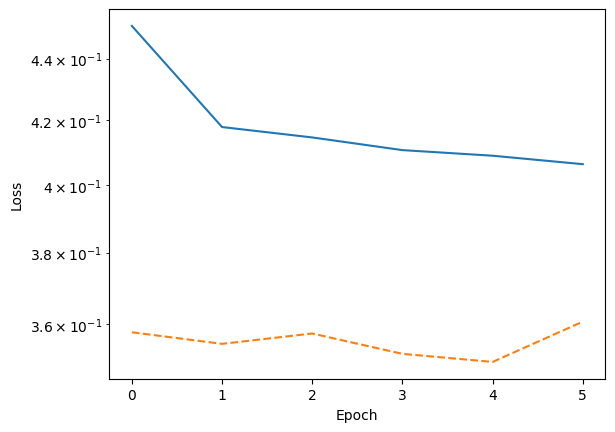

In [549]:
plotloss(history, "initial Bias")

In [476]:
def plot_metrics(history):
  metrics = ['loss', 'prc', 'precision', 'recall']
  for n, metric in enumerate(metrics):
    name = metric.replace("_"," ").capitalize()
    plt.subplot(2,2,n+1)
    plt.plot(history.epoch, history.history[metric], label='Train')
    plt.plot(history.epoch, history.history['val_'+metric], linestyle="--", label='Val')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    if metric == 'loss':
      plt.ylim([0, plt.ylim()[1]])
    elif metric == 'auc':
      plt.ylim([0.8,1])
    else:
      plt.ylim([0,1])

    plt.legend();

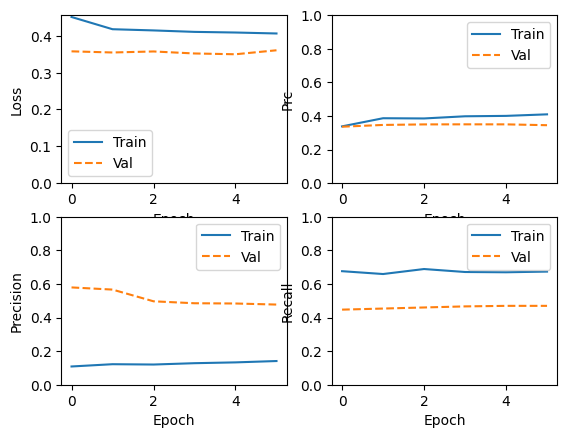

In [550]:
plot_metrics(history)

In [407]:
model.predict({'events': X_val_pad, 'timestamps': time_val_pad})

271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[0.25317368],
       [0.35531482],
       [0.24196586],
       ...,
       [0.46290213],
       [0.00334345],
       [0.29818213]], shape=(8655, 1), dtype=float32)

In [408]:
idx_1 = y_val[y_val==1].index.min()

In [409]:
idx_1

np.int64(545)

In [410]:
model.predict({'events': X_val_pad, 'timestamps': time_val_pad})[545]

271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([0.00334346], dtype=float32)

In [497]:
# Diagnostic 1 —  ce que le modèle prédit vraiment
proba = model.predict({'events': X_val_pad, 'timestamps': time_val_pad}).flatten()
print(f"min={proba.min():.3f} mean={proba.mean():.3f} max={proba.max():.3f}")
# Si max < 0.3 → le modèle prédit tout proche de 0, il a appris le biais de classe

271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
min=0.006 mean=0.277 max=0.992


In [551]:
import matplotlib.pyplot as plt

proba = model.predict({'events': X_val_pad, 'timestamps': time_val_pad}).flatten()

# Distribution des probas par classe réelle
df_proba = pd.DataFrame({'proba': proba, 'y_true': y_val})

df_proba.groupby('y_true')['proba'].plot(
    kind='hist', bins=30, alpha=0.5, legend=True
)
plt.xlabel('Probabilité prédite')
plt.title('Distribution des probas par classe')
plt.show()

print(df_proba.groupby('y_true')['proba'].describe())

ValueError: Exception encountered when calling Sequential.call().

[1mThe structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_677
Received: inputs={'events': 'Tensor(shape=(32, 16))', 'timestamps': 'Tensor(shape=(32, 16, 3))'}[0m

Arguments received by Sequential.call():
  • inputs={'events': 'tf.Tensor(shape=(32, 16), dtype=float32)', 'timestamps': 'tf.Tensor(shape=(32, 16, 3), dtype=float32)'}
  • training=False
  • mask={'events': 'None', 'timestamps': 'None'}
  • kwargs=<class 'inspect._empty'>

271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


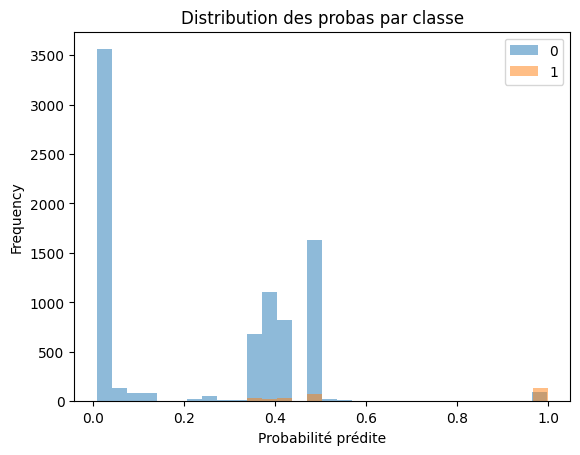

         count      mean       std       min       25%       50%       75%  \
y_true                                                                       
0       8344.0  0.242569  0.224748  0.008459  0.008459  0.359097  0.426681   
1        311.0  0.668080  0.292644  0.008459  0.426681  0.489333  0.980843   

             max  
y_true            
0       0.997966  
1       0.999342  


In [552]:
import matplotlib.pyplot as plt

proba = model.predict(X_val_pad).flatten()

# Distribution des probas par classe réelle
df_proba = pd.DataFrame({'proba': proba, 'y_true': y_val})

df_proba.groupby('y_true')['proba'].plot(
    kind='hist', bins=30, alpha=0.5, legend=True
)
plt.xlabel('Probabilité prédite')
plt.title('Distribution des probas par classe')
plt.show()

print(df_proba.groupby('y_true')['proba'].describe())

In [553]:
from sklearn.metrics import precision_recall_curve, auc, classification_report
import matplotlib.pyplot as plt

proba_val = model.predict({'events': X_val_pad, 'timestamps': time_val_pad}).flatten()
precisions, recalls, thresholds = precision_recall_curve(y_val, proba_val)

pr_auc = auc(recalls, precisions)
print(f"PR-AUC  : {pr_auc:.3f}")
print(f"Baseline: {y_val.mean():.3f}")   # ≈ 0.036 si 2005/(53089+2005)

# Seuil optimal F1
f1_scores   = 2 * (precisions[:-1] * recalls[:-1]) / \
                  (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx    = f1_scores.argmax()
best_thr    = thresholds[best_idx]

print(f"\nSeuil optimal F1 : {best_thr:.3f}")
print(f"Precision        : {precisions[best_idx]:.3f}")
print(f"Recall           : {recalls[best_idx]:.3f}")
print(f"F1               : {f1_scores[best_idx]:.3f}")

# Rapport complet
y_pred = (proba_val >= best_thr).astype(int)
print(f"\n{classification_report(y_val, y_pred, target_names=['no_purchase','purchase'])}")
# Courbe PR
plt.figure(figsize=(7, 4))
plt.plot(recalls, precisions, label=f'GRU (PR-AUC={pr_auc:.3f})')
plt.axhline(y.mean(), linestyle='--', color='gray',
            label=f'Baseline ({y.mean():.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

ValueError: Exception encountered when calling Sequential.call().

[1mThe structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_677
Received: inputs={'events': 'Tensor(shape=(32, 16))', 'timestamps': 'Tensor(shape=(32, 16, 3))'}[0m

Arguments received by Sequential.call():
  • inputs={'events': 'tf.Tensor(shape=(32, 16), dtype=float32)', 'timestamps': 'tf.Tensor(shape=(32, 16, 3), dtype=float32)'}
  • training=False
  • mask={'events': 'None', 'timestamps': 'None'}
  • kwargs=<class 'inspect._empty'>

271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
PR-AUC  : 0.378
Baseline: 0.036

Seuil optimal F1 : 0.719
Precision        : 0.576
Recall           : 0.453
F1               : 0.507

              precision    recall  f1-score   support

 no_purchase       0.98      0.99      0.98      8344
    purchase       0.58      0.45      0.51       311

    accuracy                           0.97      8655
   macro avg       0.78      0.72      0.75      8655
weighted avg       0.97      0.97      0.97      8655



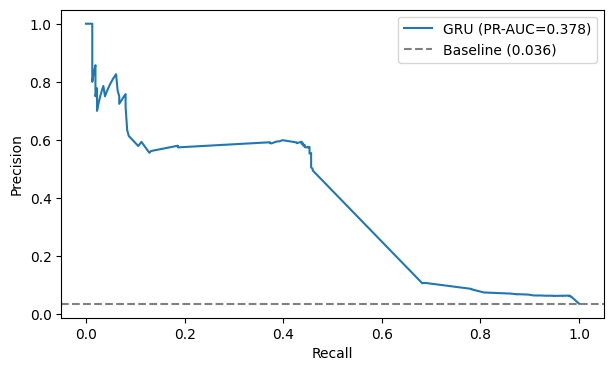

In [554]:
from sklearn.metrics import precision_recall_curve, auc, classification_report
import matplotlib.pyplot as plt

proba_val = model.predict(X_val_pad).flatten()
precisions, recalls, thresholds = precision_recall_curve(y_val, proba_val)

pr_auc = auc(recalls, precisions)
print(f"PR-AUC  : {pr_auc:.3f}")
print(f"Baseline: {y_val.mean():.3f}")   # ≈ 0.036 si 2005/(53089+2005)

# Seuil optimal F1
f1_scores   = 2 * (precisions[:-1] * recalls[:-1]) / \
                  (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx    = f1_scores.argmax()
best_thr    = thresholds[best_idx]

print(f"\nSeuil optimal F1 : {best_thr:.3f}")
print(f"Precision        : {precisions[best_idx]:.3f}")
print(f"Recall           : {recalls[best_idx]:.3f}")
print(f"F1               : {f1_scores[best_idx]:.3f}")

# Rapport complet
y_pred = (proba_val >= best_thr).astype(int)
print(f"\n{classification_report(y_val, y_pred, target_names=['no_purchase','purchase'])}")
# Courbe PR
plt.figure(figsize=(7, 4))
plt.plot(recalls, precisions, label=f'GRU (PR-AUC={pr_auc:.3f})')
plt.axhline(y.mean(), linestyle='--', color='gray',
            label=f'Baseline ({y.mean():.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()